In [2]:
from typing import TypedDict,Literal

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency: Literal['INR', 'EUR']
    total: float

In [5]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def calc_inr(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 90.0
    return state

def calc_eur(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.86
    return state

In [7]:
def choose_conversion(state: PortfolioState) -> str:
    return state['target_currency']

In [9]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total_node", calc_total)
builder.add_node("calc_inr_node", calc_inr)
builder.add_node("calc_eur_node", calc_eur)

builder.add_edge(START, "calc_total_node")
builder.add_conditional_edges(
    'calc_total_node', choose_conversion, {
        'INR': 'calc_inr_node',
        'EUR': 'calc_eur_node'
    }
)
builder.add_edge("calc_inr_node", END)
builder.add_edge("calc_eur_node", END)

graph = builder.compile()


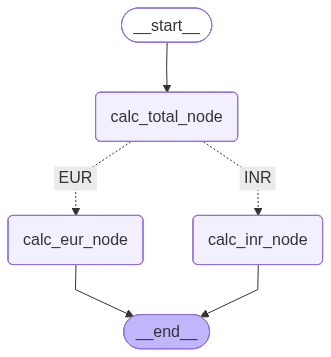

In [10]:
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))  # type: ignore

In [11]:
graph.invoke({'amount_usd': 1000.0,'target_currency':'INR'})

{'amount_usd': 1000.0,
 'total_usd': 1080.0,
 'target_currency': 'INR',
 'total': 97200.0}